# Decision Trees and Supervised Learning

Note: this is shared ``read-only`` so you should save a copy to your own Google Drive.

Diabetes is one of the leading causes of death world wide (8th in the USA). Key problems are early and correct diagnosis.

For us it's an excuse to learn a few Python commands, and have a first look at the basics of **supervised learning**.

1.  A basic intro to Python and scikit-learn
2.  The cardinal rule: always look at your data set, in any way you can.
3.  Decision Tree Classifiers
34.  Training and testing error


Data from "National Institute of Diabetes and Digestive and Kidney Diseases" available here:

https://www.kaggle.com/datasets/mathchi/diabetes-data-set/data

<img src="https://www.aces.edu/wp-content/uploads/2022/03/FCS-2561-DEEP-Diabetes-Complications-Flyer081621L.jpg" width=250px/>


## Setting Up Our Environment

We need to import the essential Python libraries that will power our analysis:

- **pandas**: For data manipulation and analysis (think of it as Excel on steroids)
- **numpy**: For numerical computations and array operations
- **matplotlib**: For creating visualizations and plots
- **scikit-learn**: Our main machine learning library (we'll import specific modules as needed)

In [ ]:
# import important python libraries
import pandas as pd # used for data manipulation and analysis.
import numpy as np # used for numerical computations.
import matplotlib.pyplot as plt # used for data visualization.


## Reproducibility in Machine Learning

In machine learning, we often use random processes (like splitting data or initializing models). Setting a random seed ensures that we get the same results every time we run our code, which is crucial for:
- Debugging our models
- Comparing different approaches fairly
- Ensuring reproducible research

This is not that important yet in this notebook, but it's good practice, so we include it.

In [ ]:
# sets the seed for NumPy's random number generator to a specific value, in this case, 42
# running code always gets same random numbers -- useful for debugging and verifying results.
np.random.seed(42)

## Load the Data

* Download the data from [this link](https://drive.google.com/file/d/1tq0aqY1Bdz3n2qc3IA0lf7o3QWgb6bXX/view?usp=sharing).
* Save in your Google Drive.

* Now let's give Colab access to our Drive

In [ ]:
# Mount Google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Read in the Data


In [ ]:
# Replace 'path_to_your_file.csv' with the actual path to your CSV file
#file_path = '/content/drive/MyDrive/Colab Notebooks/path_to_your_file.csv'
file_path = '/content/drive/MyDrive/Colab Notebooks/YouTube-Data-Sets/diabetes.csv'
diabetes_data = pd.read_csv(file_path) #reads the CSV file located at file_path,
                                       #loads the data into a Pandas DataFrame
                                       #and assigns it to the variable diabetes_data.

## Exploratory Data Analysis (EDA)

The first cardinal rule of data science: **Always look at your data!** Before building any model, we need to understand:
- What data we have
- How it's structured
- Whether it's balanced
- What patterns might exist
- Potential data quality issues

This step is crucial because the quality of our model depends entirely on the quality of our data.

In [ ]:
# Display the first few rows of the dataframe
pd.set_option('display.min_rows', 15)

print(diabetes_data.shape) # displays the number of rows and columns of the array
diabetes_data # prints the actual data

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
...,...,...,...,...,...,...,...,...,...
761,9,170,74,31,0,44.0,0.403,43,1
762,9,89,62,0,0,22.5,0.142,33,0


## What did we learn?

This is the Pima Indians Diabetes Database, a classic dataset in machine learning. This dataset contains medical information from 768 female patients of Pima Indian heritage, with the goal of predicting whether a patient has diabetes based on various diagnostic measurements.

**Key Features:**
- **Pregnancies**: Number of times pregnant
- **Glucose**: Plasma glucose concentration (mg/dL)
- **Blood Pressure**: Diastolic blood pressure (mm Hg)
- **Skin Thickness**: Triceps skin fold thickness (mm)
- **Insulin**: 2-Hour serum insulin (mu U/ml)
- **BMI**: Body mass index (weight in kg/(height in m)²)
- **Diabetes Pedigree Function**: Diabetes family history
- **Age**: Age in years

**Target Variable:**
- **Outcome**: 0 (non-diabetic) or 1 (diabetic)

### What else can we learn?

1. Balanced dataset? How many have diabetes?
2. Let's plot subset of the columns (2 at a time). Need to learn how to do scatter plots.
3. Other ideas we could do?

### Understanding Class Distribution

Let's examine how many patients have diabetes vs. those who don't. This is crucial because:
- **Imbalanced datasets** can lead to biased models
- We need to understand if our model should focus on precision, recall, or accuracy
- It helps us choose appropriate evaluation metrics

In [ ]:
diabetes_data['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


### Visualizing Relationships Between Features

Scatter plots are powerful tools for understanding relationships between variables. For starters, we plot Glucose vs. BMI to see if there are any clear patterns that separate diabetic from non-diabetic patients.

We use ``Matplotlib`` for the visualization.

**What to look for:**
- Clear separation between classes
- Clusters or patterns
- Outliers or data quality issues
- Linear or non-linear relationships

In [ ]:
# We extract the two features we want to plot
# and we also convert the data into a numpy array

diabetes_data.columns # get the names of the columns
X = diabetes_data[['Glucose', 'BMI']].values
y = diabetes_data['Outcome'].values

# Create a scatter plot (διάγραμμα διασποράς)
plt.figure(figsize=(10, 6)) #This function creates a new figure, which is a container for all the plot elements and sets the width of the figure to 10 inches and the height to 6 inches
for i in range(len(X)): #from 1 to 768 which is the length of the array
    if y[i] == 0: #if outcome is 0
        plt.scatter(X[i, 0], X[i, 1], color='blue', label='Outcome 0' if 'Outcome 0' not in plt.gca().get_legend_handles_labels()[1] else "")
    else: #if outcome is 1
        plt.scatter(X[i, 0], X[i, 1], color='red', label='Outcome 1' if 'Outcome 1' not in plt.gca().get_legend_handles_labels()[1] else "")

# Adding labels and title
plt.xlabel('Glucose')
plt.ylabel('BMI')
plt.title('Scatter Plot of Glucose vs BMI')
plt.legend()
plt.show() # plot current figure to screen


### Data Quality Issues

Notice that some patients have values of 0 for Glucose or BMI, which is biologically impossible. These are likely missing values that were encoded as 0.

There are several choices for the data scientist at this point in terms of how to handle these data.
* We could simply remove any data point with even a single missing entry.
* Instead we could *impute* the missing values, e.g., by using the mean or median of that feature across the other data, or some more sophisticated method.

**This matters:** Including biologically impossible values can mislead our model and reduce its performance. But how we decide to handle the missing data will also impact our model.

For now, we choose the simpler of the above options: We'll filter out any rows that have missing data.


In [ ]:
filtered_data = diabetes_data[(diabetes_data['Glucose'] != 0) & (diabetes_data['BMI'] != 0)]
X = filtered_data[['Glucose', 'BMI']].values
y = filtered_data['Outcome'].values


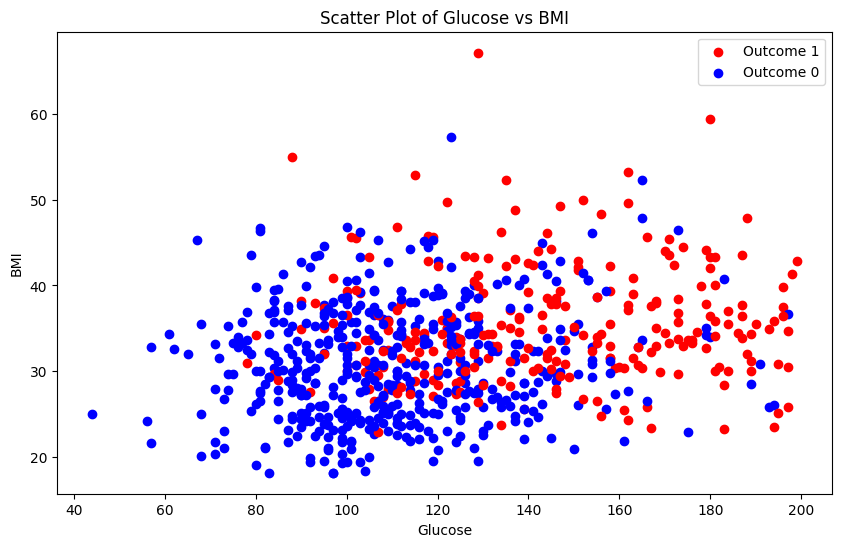

In [ ]:
# Create a scatter plot
plt.figure(figsize=(10, 6)) #This function creates a new figure, which is a container for all the plot elements and sets the width of the figure to 10 inches and the height to 6 inches
for i in range(len(X)): #from 1 to 768 which is the length of the array
    if y[i] == 0: #if outcome is 0
        plt.scatter(X[i, 0], X[i, 1], color='blue', label='Outcome 0' if 'Outcome 0' not in plt.gca().get_legend_handles_labels()[1] else "")
    else: #if outcome is 1
        plt.scatter(X[i, 0], X[i, 1], color='red', label='Outcome 1' if 'Outcome 1' not in plt.gca().get_legend_handles_labels()[1] else "")

# Adding labels and title
plt.xlabel('Glucose')
plt.ylabel('BMI')
plt.title('Scatter Plot of Glucose vs BMI')
plt.legend()
plt.show() # plot current figure to screen


## Training a decision tree

Decision trees are one of the most intuitive machine learning algorithms. They work by asking a series of yes/no questions to classify data points.

For us, they also serve to illustrate the main flow that we'll be using even when we develop much more sophisticated algorithms:

**The Basic Workflow:**
1. **Create a model** with specific parameters
2. **Train the model** on our data (fit)
3. **Make predictions** on new data
4. **Evaluate performance** using appropriate metrics


### Basic paradigm of building a model and training:
```
model = FamilyOfModels(some parameters)
model.fit(X,y)
model.predict(x)
```

## SKLEARN

``sklearn`` is a Python library with many algorithms, as well as helper functions. We will be using ``sklearn`` extensively.

In [ ]:
# import the necessary libraries
from sklearn import tree #import the tree module from the scikit-learn library
from sklearn.tree import DecisionTreeClassifier # used to create a decision tree classifier
from sklearn.metrics import accuracy_score # used to calculate the accuracy of a classification model

### Training a Decision Stump (Depth 1 Tree)

A decision stump is the simplest possible decision tree - it makes only one split. This is perfect for understanding how decision trees work.

**What we're doing:**
1. Create a tree that can only make one decision
2. Train it on our data
3. Visualize the decision boundary
4. Calculate accuracy

**Expected outcome:** A single horizontal or vertical line dividing our 2D space.

In [ ]:
decision_stump = DecisionTreeClassifier(max_depth=1)
decision_stump.fit(X,y)

### Plot the Decision Region

The code below is useful. We will be cutting-and-pasting essentially identical code to plot decision regions.

Try to parse it to understand what it's doing, and in particular, how it is using the ``model.predict`` part of the above flow.

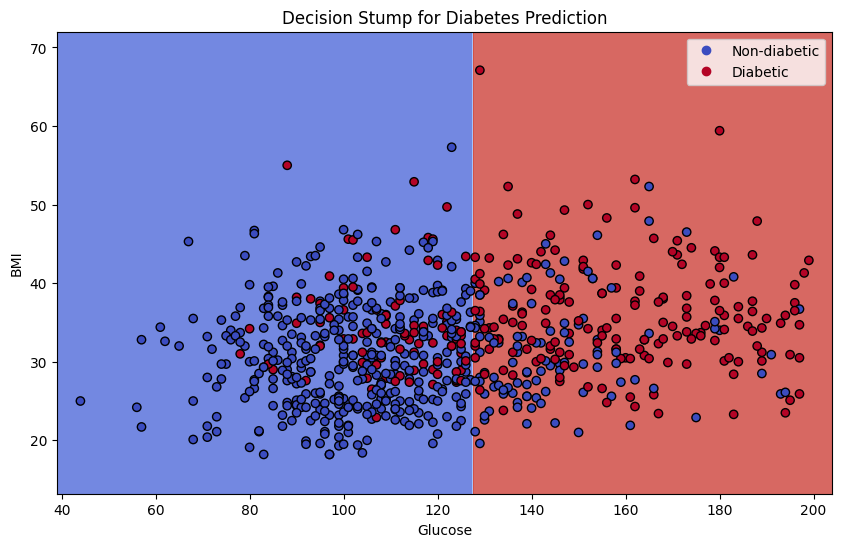

In [ ]:
# Define the grid range based on your data
x_min, x_max = X[:, 0].min() - 5, X[:, 0].max() + 5
y_min, y_max = X[:, 1].min() - 5, X[:, 1].max() + 5

# Create a meshgrid
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))
# Predict the outcome on the meshgrid
Z = decision_stump.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)

# Plot the training points
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolor='k')
plt.xlabel('Glucose')
plt.ylabel('BMI')
plt.title('Decision Stump for Diabetes Prediction')
plt.legend(handles=scatter.legend_elements()[0], labels=['Non-diabetic', 'Diabetic'])
plt.show()


### Understanding the Tree Structure

The tree visualization shows us exactly how our model makes decisions:
- **Root node**: The first question asked
- **Internal nodes**: Additional questions
- **Leaf nodes**: Final predictions
- **Samples**: Number of data points at each node
- **Value**: Distribution of classes at each node

[Text(0.5, 0.75, 'x[0] <= 127.5\ngini = 0.456\nsamples = 752\nvalue = [488, 264]'),
 Text(0.25, 0.25, 'gini = 0.31\nsamples = 470\nvalue = [380, 90]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.473\nsamples = 282\nvalue = [108, 174]'),
 Text(0.625, 0.5, '  False')]

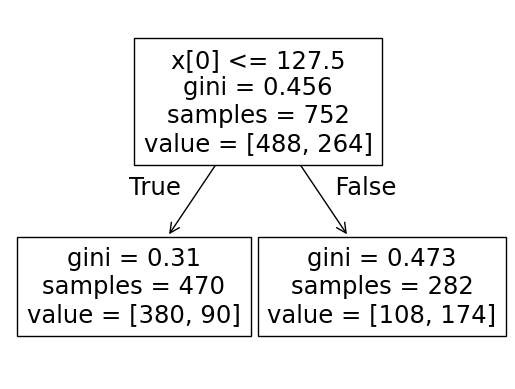

In [ ]:
tree.plot_tree(decision_stump)

In [ ]:
# What's the accuracy?

y_pred = decision_stump.predict(X)
accuracy_score(y, y_pred)

0.7367021276595744

### The Bias-Variance Tradeoff

Now let's explore one of the most fundamental concepts in machine learning: the bias-variance tradeoff.

**What we'll test:**
- **Depth 1 tree**: High bias, low variance (simple model)
- **Depth 3 tree**: Moderate bias and variance
- **Depth 15 tree**: Low bias, high variance (complex model)

We will revisit these terms (simple, complex, bias, variance) in subsequent lectures.

**Key Question:** Which model will perform better on our training data? And more importantly, which will generalize better to new data?

In [ ]:
model = DecisionTreeClassifier(max_depth=3)
model.fit(X,y)
y_pred2 = model.predict(X)
accuracy_score(y, y_pred2)

0.773936170212766

### Visualizing Decision Boundaries

The colored regions show how each model divides the feature space:
- **Red regions**: Predicted as diabetic
- **Blue regions**: Predicted as non-diabetic
- **Points**: Actual data (colored by true outcome)

**What to observe:**
- How the boundary complexity changes with tree depth
- Whether the model is capturing real patterns or just memorizing the data


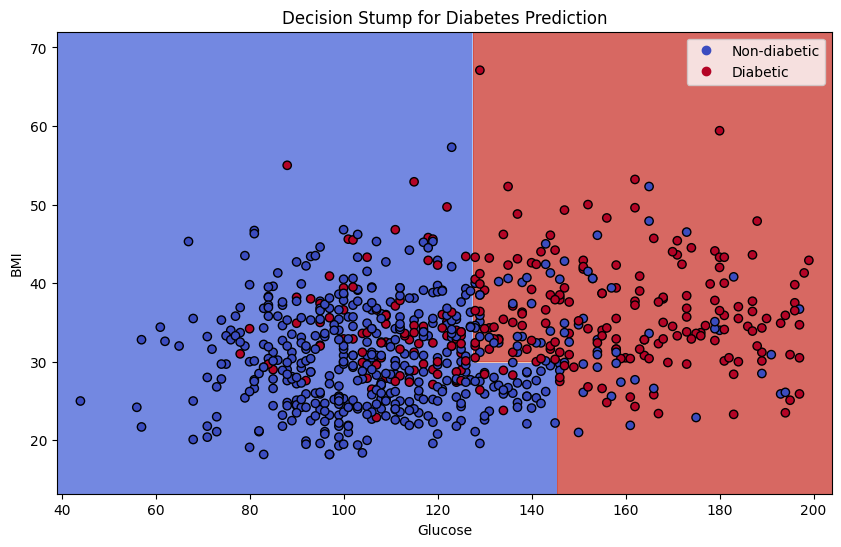

In [ ]:
# Define the grid range based on your data
x_min, x_max = X[:, 0].min() - 5, X[:, 0].max() + 5
y_min, y_max = X[:, 1].min() - 5, X[:, 1].max() + 5

# Create a meshgrid
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))
# Predict the outcome on the meshgrid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)

# Plot the training points
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolor='k')
plt.xlabel('Glucose')
plt.ylabel('BMI')
plt.title('Decision Stump for Diabetes Prediction')
plt.legend(handles=scatter.legend_elements()[0], labels=['Non-diabetic', 'Diabetic'])
plt.show()


In [ ]:
model = DecisionTreeClassifier(max_depth=15)
model.fit(X,y)
y_pred2 = model.predict(X)
accuracy_score(y, y_pred2)

0.9680851063829787

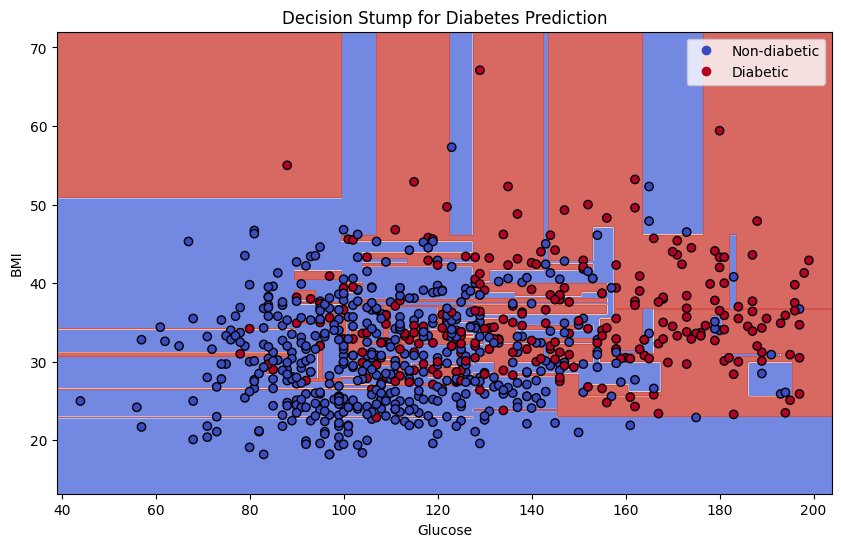

In [ ]:
# Define the grid range based on your data
x_min, x_max = X[:, 0].min() - 5, X[:, 0].max() + 5
y_min, y_max = X[:, 1].min() - 5, X[:, 1].max() + 5

# Create a meshgrid
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))
# Predict the outcome on the meshgrid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)

# Plot the training points
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolor='k')
plt.xlabel('Glucose')
plt.ylabel('BMI')
plt.title('Decision Stump for Diabetes Prediction')
plt.legend(handles=scatter.legend_elements()[0], labels=['Non-diabetic', 'Diabetic'])
plt.show()


## Beyond Decision Trees: Other Classification Models

Decision trees are just one approach to classification. Let's briefly introduce two other popular methods:

**Logistic Regression:**
- Assumes a linear relationship between features and the log-odds of the target
- Often serves as a baseline model
- Provides probability estimates

**XGBoost:**
- An ensemble method that combines multiple decision trees
- Generally provides better performance than single trees
- More complex but often more accurate

We will discuss each of these in much more depth in the sequel. For now, they serve to illustrate the power and flexibility of our simple approach:
```
model = FamilyOfModels()
model.fit(X,y)
model.predict(X)
```

**Why compare models?** As we add more models to our arsenal of tools, we will see that different algorithms have different strengths and weaknesses, and the best choice depends on our specific problem and data. But we need rigorous tools and statistical ideas to explore the pros and cons of each algorithm.


### Try:

1. Logistic regression
```
from sklearn.linear_model import LogisticRegression
```
2. XGBoost
```
from xgboost import XGBClassifier
```

## Question: which is better?

We have seen depth_k decision trees, logistic regression, and XGBoost. Which of all these is the best for our dataset? How do we make this decision?